In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf # pip install yfinance

In [ ]:
tickers = ["AIRR","SPY","SCHG","VUG","MGK","XLY","IYW","PSI","FDN","IGM","FTEC","XLK","VGT","SOXX","GLD","XAR","VPU","XLV","PHO","ARKW"]
# calculate simple returns
# def calc_returns(prices: np.ndarray) -> np.ndarray:
#     returns = np.diff(prices) / prices[:-1]
#     return returns
# brug dette i stedet:
#returns = calc_returns(close_prices.values.flatten())

# raw month end to month end returns -----------------------------------
data = yf.download(
    tickers,
    start="2010-01-01",
    end="2020-12-31",
    interval="1d", # 1d, 1mo, 1wk, 1h, 5m, 15m, 30m, 60m
   auto_adjust=False,
    progress=False
)

# we define the monthly price as the last daily close in each month
                  
monthly_prices = data["Close"].resample("M").last() # .first() for open, .last() for close
monthly_ROR_test = monthly_prices.pct_change().dropna(how="any")
monthly_ROR_test


#https://fred.stlouisfed.org/data/NASDAQ100
#https://fred.stlouisfed.org/data/SP500
#https://fred.stlouisfed.org/data/NASDAQCOM



Ticker,AIRR,ARKW,FDN,FTEC,GLD,IGM,IYW,MGK,PHO,PSI,SCHG,SOXX,SPY,VGT,VPU,VUG,XAR,XLK,XLV,XLY
Date,,,,,,,,,,,,,,,,,,,,
2014-10-31,0.048818,0.017009,0.002299,0.019276,-0.030548,0.009909,0.008634,0.028413,0.049980,0.003478,0.028670,0.003454,0.023551,0.019085,0.083662,0.029999,0.040300,0.016040,0.052574,0.021143
2014-11-30,-0.048312,0.018642,0.018185,0.048256,-0.004882,0.047643,0.051166,0.030879,-0.000774,0.065425,0.030836,0.072174,0.027472,0.049907,0.008084,0.030586,0.032971,0.048101,0.034785,0.054479
2014-12-31,0.000546,-0.008644,-0.013355,-0.014308,0.013112,-0.015931,-0.022746,-0.014431,-0.002711,0.035380,-0.006903,-0.005886,-0.008012,-0.024281,0.025962,-0.013327,0.016657,-0.026830,-0.017670,0.004735
2015-01-31,-0.089853,-0.002923,-0.019406,-0.035658,0.086899,-0.036990,-0.038697,-0.014150,-0.052039,-0.020817,-0.013130,-0.048660,-0.029629,-0.035126,0.021788,-0.015231,-0.016476,-0.035066,0.013015,-0.029938
2015-02-28,0.107115,0.082560,0.099784,0.082788,-0.059052,0.083749,0.083798,0.062656,0.039738,0.082631,0.065545,0.096073,0.056205,0.083325,-0.059380,0.062451,0.086459,0.079950,0.042876,0.085441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-31,0.093636,0.130465,0.079204,0.112474,-0.003236,0.098459,0.116170,0.113787,0.016183,-0.005922,0.097998,0.057957,0.069797,0.111356,-0.025411,0.100934,0.056419,0.118808,0.025869,0.095547
2020-09-30,-0.049612,-0.034409,-0.050708,-0.051221,-0.041714,-0.055498,-0.056739,-0.054371,0.003033,-0.039096,-0.041129,-0.008496,-0.041281,-0.050891,-0.001160,-0.048891,-0.034277,-0.055443,-0.025679,-0.020721
2020-10-31,0.032363,0.020350,-0.007009,-0.042907,-0.005194,-0.026823,-0.027668,-0.034250,0.027470,0.036812,-0.028393,0.002856,-0.024934,-0.043217,0.048877,-0.030051,-0.025418,-0.050043,-0.036215,-0.027283


In [31]:
# save R into CSV file

path = "monthly_ROR_2010_2020.csv"
monthly_ROR_test.to_csv(path, index=True)


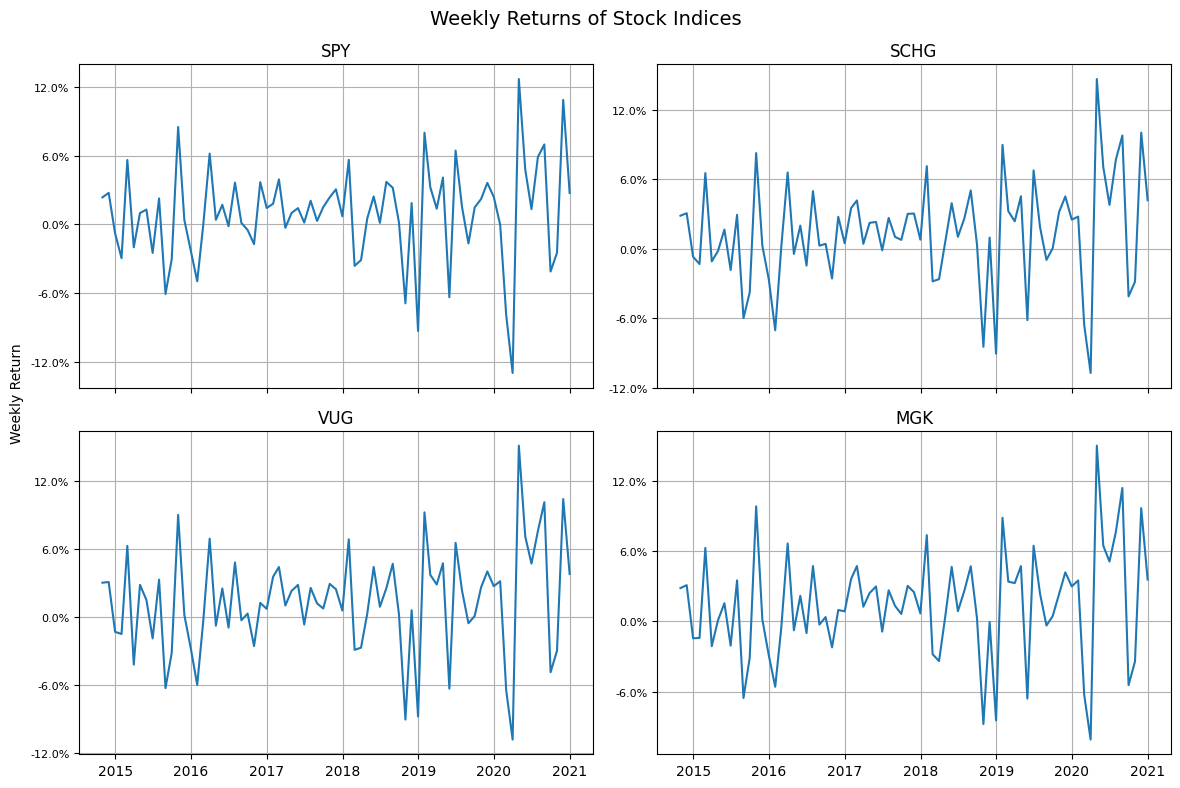

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = axes.flatten()

for i, ticker in enumerate(tickers[1:5]):  # plot the first 4 tickers for better visibility
    axes[i].plot(monthly_ROR_test.index, monthly_ROR_test[ticker])
    axes[i].set_title(ticker)
    axes[i].yaxis.set_major_locator(plt.MaxNLocator(5))
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
    axes[i].tick_params(axis='y', labelsize=8)
    axes[i].grid()

fig.suptitle("Weekly Returns of Stock Indices", fontsize=14)
fig.supylabel("Weekly Return", fontsize=10)  # single shared y label
plt.tight_layout()
plt.show()

In [33]:
R = monthly_ROR_test.to_numpy()
print(R.shape)
T, n = R.shape
print(f"Shape of R: {R.shape}")
mu_assets = R.mean(axis=0)  
print(f"Mean returns (mu_assets): {mu_assets}")
sigma_assets = R.std(axis=0, ddof=1)
print(f"Standard deviations (sigma_assets): {sigma_assets}")

#p = np.ones(T) / T 



(75, 20)
Shape of R: (75, 20)
Mean returns (mu_assets): [0.01050036 0.03005556 0.01830395 0.01810193 0.00648903 0.01842772
 0.01773604 0.01394037 0.0094267  0.02295565 0.01388226 0.02190823
 0.0094147  0.01833757 0.00600818 0.01354602 0.01300621 0.01713169
 0.00840557 0.01305448]
Standard deviations (sigma_assets): [0.06814899 0.078787   0.05528773 0.05297449 0.04084555 0.0523893
 0.05312089 0.04625584 0.04578927 0.07218297 0.04544434 0.0655023
 0.04273321 0.05300851 0.03893787 0.04643206 0.062111   0.05113013
 0.04194214 0.05071202]
